In [3]:

!pip install wordcloud


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud  
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import hamming_loss
from sklearn.metrics import accuracy_score
import joblib

In [12]:
df = pd.read_csv("train.csv.gz")

df.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [13]:
def audit(df):
    print("shape:",df.shape),
    print("columns:",df.columns),
    print("data_types:",df.dtypes),
    print("null_values:",df.isnull().sum()),
    print("duplicate_rows:",df.duplicated().sum()),
    print("Summary:\n", df.describe()),
    print("info:",df.info())


audit(df)

shape: (159571, 8)
columns: Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')
data_types: id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object
null_values: id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64
duplicate_rows: 0
Summary:
                toxic   severe_toxic        obscene         threat  \
count  159571.000000  159571.000000  159571.000000  159571.000000   
mean        0.095844       0.009996       0.052948       0.002996   
std         0.294379       0.099477       0.223931       0.054650   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50

In [14]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df[labels].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

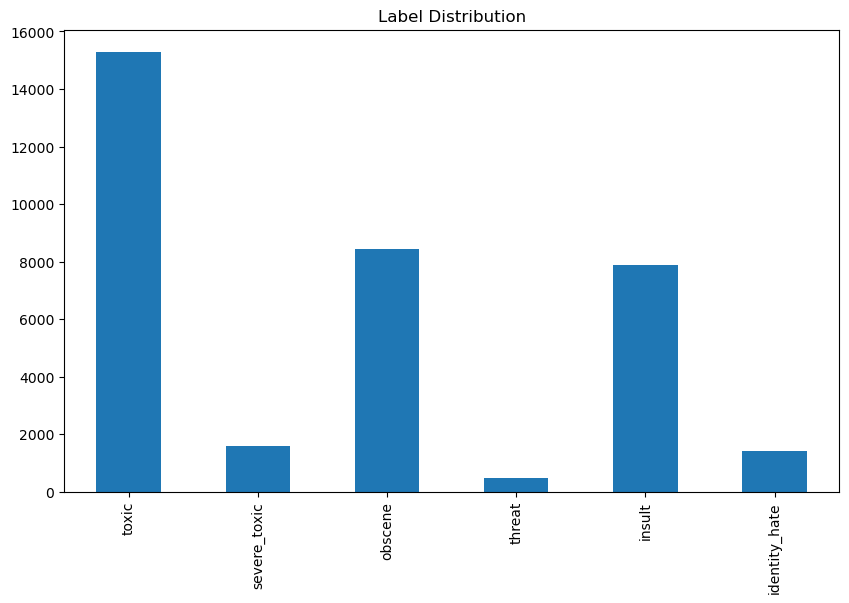

In [17]:
counts = df[labels].sum()

plt.figure(figsize=(10,6))

counts.plot(kind='bar')

plt.title("Label Distribution")

plt.show()

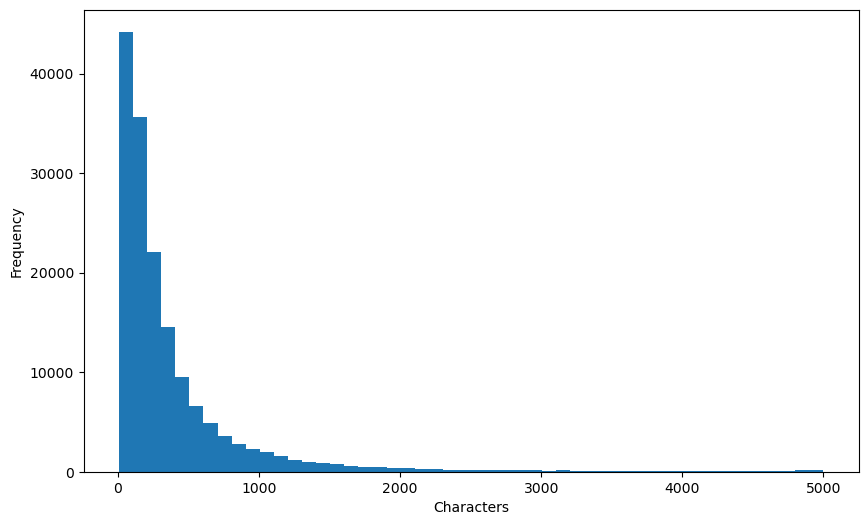

In [22]:
df["comment_length"] = df["comment_text"].apply(len)

plt.figure(figsize=(10,6))

plt.hist(df["comment_length"],bins=50)

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [23]:
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhara\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhara\AppData\Roaming\nltk_data...


In [26]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+"," ",text)

    text = re.sub(r"<.*?>"," ",text)

    text = re.sub(r"\d+"," ",text)

    text = text.translate(
        str.maketrans("","",string.punctuation)
    )

    words = []

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)

df["clean_text"] = df["comment_text"].apply(clean_text)

In [28]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,clean_text
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,explanation edits made username hardcore metal...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,daww match background colour im seemingly stuc...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,hey man im really trying edit war guy constant...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,cant make real suggestion improvement wondered...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,sir hero chance remember page thats


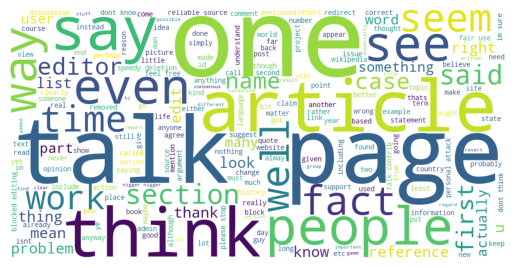

In [30]:
text = " ".join(df["clean_text"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.imshow(wc)

plt.axis("off")

plt.show()

In [31]:
X = df["clean_text"]

y = df[labels]

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42
)


In [32]:
tfidf = TfidfVectorizer(

    max_features=30000,

    ngram_range=(1,2),

    min_df=5,

    max_df=0.8
)

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [53]:
svm = OneVsRestClassifier(

    LinearSVC(random_state=42))

svm.fit(X_train,y_train)

pred = svm.predict(X_test)

pred = svm.predict(X_test)

pd.DataFrame(pred, columns=y_train.columns).sum()

toxic            3038
severe_toxic      182
obscene          1667
threat             45
insult           1420
identity_hate     141
dtype: int64

In [37]:
from sklearn.metrics import classification_report

prediction = svm.predict(X_test)

print(

    classification_report(
        y_test,
        prediction,
        target_names=labels,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.86      0.69      0.77      3815
 severe_toxic       0.53      0.24      0.33       406
      obscene       0.89      0.69      0.78      2143
       threat       0.58      0.25      0.35       105
       insult       0.80      0.56      0.66      2011
identity_hate       0.65      0.26      0.37       357

    micro avg       0.84      0.62      0.71      8837
    macro avg       0.72      0.45      0.54      8837
 weighted avg       0.83      0.62      0.70      8837
  samples avg       0.06      0.06      0.06      8837

